['.DS_Store', 'real', 'ai']
Found 962 files belonging to 2 classes.
Using 770 files for training.
Found 962 files belonging to 2 classes.
Using 192 files for validation.
Klassar: ['ai', 'real']
Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 649ms/step - accuracy: 0.4935 - loss: 0.7378 - val_accuracy: 0.5260 - val_loss: 0.7020
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 604ms/step - accuracy: 0.5623 - loss: 0.6940 - val_accuracy: 0.5885 - val_loss: 0.6571
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 632ms/step - accuracy: 0.6273 - loss: 0.6420 - val_accuracy: 0.6354 - val_loss: 0.6260
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 608ms/step - accuracy: 0.6494 - loss: 0.6089 - val_accuracy: 0.6510 - val_loss: 0.6087
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 660ms/step - accuracy: 0.6922 - loss: 0.5784 - val_accuracy: 0.6771 - val_loss: 0.5830
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.7273 - loss: 0.5610 - val_accuracy: 0.6823 - val_loss: 0.5759
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━

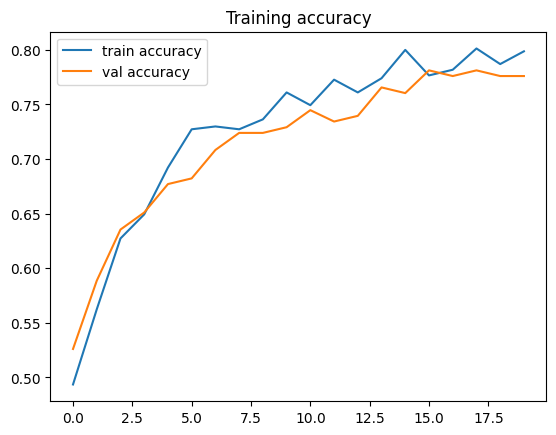

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
print(os.listdir("art"))

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt


# Innstillingar
DATA_DIR = "art"
IMG_SIZE = (228, 228)
BATCH_SIZE = 64
EPOCHS = 20

# Last inn trenings- og valideringsdata
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Klassar:", class_names)

# Gjer dataflyten raskare
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Pretrained base model
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(228, 228, 3)
)

base_model.trainable = False  # frys først

# Bygg modellen
inputs = tf.keras.Input(shape=(228, 228, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Tren modellen
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# Lagre modellen
os.makedirs("models", exist_ok=True)
model.save("models/ai_vs_real_model.keras")

# Plot accuracy
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.legend()
plt.title("Training accuracy")
plt.savefig("results_accuracy.png")
plt.show()

In [7]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(path):
    img = load_img(path, target_size=(150, 150))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction >= 0.5:
        label = "real"
    else:
        label = "ai"

    confidence = prediction if prediction >= 0.5 else 1 - prediction

    print(f"{path} → {label} ({confidence:.2%})")



In [9]:
images = [
    "new_images/test1.jpg",
    "new_images/test2.jpg",
    "new_images/test3.jpg",
]

for img in images:
    predict_image(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
new_images/test1.jpg → ai (82.85%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
new_images/test2.jpg → real (70.26%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
new_images/test3.jpg → ai (63.18%)
